In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, ArrayType, MapType
import pandas as pd


In [2]:
import sys
import os
import time
# Add the src/ directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src/")))

In [3]:
# Check if there's an active Spark context and stop it
from pyspark import SparkContext
if SparkContext._active_spark_context:
    print("Stopping existing Spark context...")
    SparkContext._active_spark_context.stop()
    print("Previous Spark context stopped successfully")

In [4]:
# Set environment variables
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

# Create new session with explicit local binding
spark = SparkSession.builder \
    .appName("EEG_Analysis") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.host", "127.0.0.1") \
    .master("local[*]") \
    .getOrCreate()

print("New Spark session created successfully")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/06 11:49:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/04/06 11:49:17 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/04/06 11:49:17 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


New Spark session created successfully


In [5]:
spark = SparkSession.builder.appName("MyApp").getOrCreate()


25/04/06 11:49:18 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [6]:
from populate_schemas import load_subjects_df, extract_features_udtf
from feature_extraction import processEpoch, processSub
from schema_definition import get_feature_schema, get_subject_schema


# from feature_extraction

In [7]:
# preprocess_sets.setProjectRootDir()
subject_df = load_subjects_df(spark)


In [8]:
ROOT_DIR = ".."
SRC_DIR = ROOT_DIR + "/src"

In [9]:
sc = spark.sparkContext
# Add all necessary modules
try:
    sc.addPyFile(os.path.join(SRC_DIR, "feature_extraction.py"))
    print("Added feature_extraction.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "preprocess_sets.py"))
    print("Added preprocess_sets to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "schema_definition.py"))
    print("Added schema_definition.py to the pyspark context")
except Exception as e:
    print(f"Error adding files to SparkContext: {e}")

Added feature_extraction.py to the pyspark context
Added preprocess_sets to the pyspark context
Added schema_definition.py to the pyspark context


In [10]:
%%time
result = (
    subject_df
    .filter((subject_df.SubjectID == "sub-001"))
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)
result.show()

/Users/admin/neuro-venv/lib/python3.9/site-packages/pyspark/sql/pandas/group_ops.py:104: UserWarning: It is preferred to use 'applyInPandas' over this API. This API will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(
function ran                                                        (0 + 1) / 1]
Processing subject sub-001
processSub sub-001
subPath sub-001
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set
Got 398 epochs for sub-001
<class 'mne.epochs.Epochs'>
Epoch 0
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
Epoch 1
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
Total rows collected: 37810
Returning DataFrame with 37810 rows
Column names from schema: ['SubjectID', 'EpochID', 'WaveBand', 'Electrode', 'Power']
4.775382041931152
                                                                                

+---------+-------+--------+---------+--------------------+
|SubjectID|EpochID|WaveBand|Electrode|               Power|
+---------+-------+--------+---------+--------------------+
|  sub-001|   ep-0|   Delta|      Fp1| 0.08257892642542033|
|  sub-001|   ep-0|   Theta|      Fp1|0.005611645685714301|
|  sub-001|   ep-0|   Alpha|      Fp1|0.001143220388171...|
|  sub-001|   ep-0|    Beta|      Fp1|1.958040080323613...|
|  sub-001|   ep-0|   Total|      Fp1|0.011235955056179773|
|  sub-001|   ep-0|   Delta|      Fp2| 0.08389220643958975|
|  sub-001|   ep-0|   Theta|      Fp2|0.004672355992737972|
|  sub-001|   ep-0|   Alpha|      Fp2|9.638188967593915E-4|
|  sub-001|   ep-0|    Beta|      Fp2|1.768820461211869...|
|  sub-001|   ep-0|   Total|      Fp2|0.011235955056179771|
|  sub-001|   ep-0|   Delta|       F3| 0.08212274846138015|
|  sub-001|   ep-0|   Theta|       F3|0.005595318986261473|
|  sub-001|   ep-0|   Alpha|       F3|0.001112336388491...|
|  sub-001|   ep-0|    Beta|       F3|2.

In [11]:
%%time
# Start both groups processing (lazy evaluation means these won't execute yet)
result_group_a = (
    subject_df
    .filter(subject_df.Group == "A")
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)

result_group_c = (
    subject_df
    .filter(subject_df.Group == "C")
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)

# Force execution of both by calling an action on each
# This launches both jobs in parallel
from pyspark.sql import functions as F

# Use persist to cache the results in memory
result_group_a = result_group_a.persist()
result_group_c = result_group_c.persist()

# Trigger execution with actions
count_a = result_group_a.count()
count_c = result_group_c.count()

print(f"Processed {count_a} records for Alzheimer's group")
print(f"Processed {count_c} records for Control group")

function ran==========================================>        (168 + 10) / 200]
Processing subject sub-012
processSub sub-012
function ran
function ran
Processing subject sub-011
processSub sub-011
Processing subject sub-016
processSub sub-016
function ran
Processing subject sub-017
processSub sub-017
function ran
Processing subject sub-020
processSub sub-020
function ran
Processing subject sub-021
processSub sub-021
function ran
Processing subject sub-001
processSub sub-001
function ran
Processing subject sub-018
processSub sub-018
function ran
Processing subject sub-029
processSub sub-029
function ran
Processing subject sub-002
processSub sub-002
subPath sub-017
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-017/eeg/sub-017_task-eyesclosed_eeg.set
subPath sub-016
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-016/eeg/sub-016_task-eyesclosed_eeg.set
subPath sub-012
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-012/eeg/sub-012_task-eyesclosed_eeg.set
subPath sub-001
Pa

Processed 1856870 records for Alzheimer's group
Processed 1543465 records for Control group
CPU times: user 323 ms, sys: 222 ms, total: 545 ms
Wall time: 4min 14s


In [14]:
result_group_a.show

<bound method DataFrame.show of DataFrame[SubjectID: string, EpochID: string, WaveBand: string, Electrode: string, Power: double]>

In [15]:
result_group_a.show(2)

+---------+-------+--------+---------+--------------------+
|SubjectID|EpochID|WaveBand|Electrode|               Power|
+---------+-------+--------+---------+--------------------+
|  sub-020|   ep-0|   Delta|      Fp1| 0.07823378995458571|
|  sub-020|   ep-0|   Theta|      Fp1|0.006522342449441742|
+---------+-------+--------+---------+--------------------+
only showing top 2 rows



In [18]:
from pyspark.sql.functions import col, mean as _mean, stddev as _stddev, broadcast, lit
from pyspark.sql.types import FloatType

# Step 1: Convert Power to float32
result_group_a = result_group_a.withColumn("Power", col("Power").cast(FloatType()))
result_group_c = result_group_c.withColumn("Power", col("Power").cast(FloatType()))
result_group_a_norm = result_group_a.withColumn("label", lit(1))
result_group_c_norm = result_group_c.withColumn("label", lit(0))

In [19]:
# Step 2: Compute mean and std from result_group_a only * added union
full_df = result_group_a.union(result_group_c)
norm_stats = full_df.groupBy("Electrode", "WaveBand").agg(
    _mean("Power").alias("mean_power"),
    _stddev("Power").alias("std_power")
)

In [20]:
norm_stats.head(3)

[Row(Electrode='T5', WaveBand='Alpha', mean_power=0.005252557521045713, std_power=0.006567790853310042),
 Row(Electrode='Pz', WaveBand='Alpha', mean_power=0.0031537372083167274, std_power=0.0038182864201296986),
 Row(Electrode='F4', WaveBand='Delta', mean_power=0.07971921558250293, std_power=0.007917400290853086)]

In [21]:
# Step 3: Broadcast join stats to both result_group_a and result_group_c
full_df = full_df.join(
    broadcast(norm_stats), on=["Electrode", "WaveBand"]
)


In [22]:
full_df.head(3)

[Row(Electrode='Fp1', WaveBand='Delta', SubjectID='sub-020', EpochID='ep-0', Power=0.07823379337787628, mean_power=0.07929838219624444, std_power=0.008222817358672627),
 Row(Electrode='Fp1', WaveBand='Theta', SubjectID='sub-020', EpochID='ep-0', Power=0.006522342562675476, mean_power=0.005327228971971614, std_power=0.003931092935816067),
 Row(Electrode='Fp1', WaveBand='Alpha', SubjectID='sub-020', EpochID='ep-0', Power=0.00359321478754282, mean_power=0.002659409741484907, std_power=0.0030160173288932383)]

In [23]:
from pyspark.sql.functions import when

full_df_norm = full_df.withColumn(
    "Power",
    (col("Power") - col("mean_power")) /
    when((col("std_power").isNotNull()) & (col("std_power") != 0), col("std_power")).otherwise(1.0) #this otherwise sets std to 1 and since std is 0 mean_power - power = 0
)



In [24]:
# Step 5 (optional): Drop extra columns
full_df_norm = full_df_norm.drop("mean_power", "std_power")

In [25]:
full_df_norm.show(10)

+---------+--------+---------+-------+--------------------+
|Electrode|WaveBand|SubjectID|EpochID|               Power|
+---------+--------+---------+-------+--------------------+
|      Fp1|   Delta|  sub-020|   ep-0|-0.12946764739281624|
|      Fp1|   Theta|  sub-020|   ep-0|  0.3040156033491905|
|      Fp1|   Alpha|  sub-020|   ep-0| 0.30961527876916517|
|      Fp1|    Beta|  sub-020|   ep-0|-0.44430232368623573|
|      Fp1|   Total|  sub-020|   ep-0|                 0.0|
|      Fp2|   Delta|  sub-020|   ep-0|-0.18955361367211143|
|      Fp2|   Theta|  sub-020|   ep-0|  0.4048158529054603|
|      Fp2|   Alpha|  sub-020|   ep-0| 0.14924802208200036|
|      Fp2|    Beta|  sub-020|   ep-0|-0.23126612915226288|
|      Fp2|   Total|  sub-020|   ep-0|                 0.0|
+---------+--------+---------+-------+--------------------+
only showing top 10 rows



In [26]:
from pyspark.sql.functions import concat_ws

full_df_norm = full_df_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)

In [27]:
full_df_norm.filter((col("Electrode") == "F3") & (col("WaveBand") == "Total")).show()


+---------+--------+---------+-------+-----+------------------+
|Electrode|WaveBand|SubjectID|EpochID|Power|Electrode_WaveBand|
+---------+--------+---------+-------+-----+------------------+
|       F3|   Total|  sub-020|   ep-0|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-1|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-2|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-3|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-4|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-5|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-6|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-7|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-8|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-9|  0.0|          F3_Total|
|       F3|   Total|  sub-020|  ep-10|  0.0|          F3_Total|
|       F3|   Total|  sub-020|  ep-11|  0.0|          F3_Total|
|       F3|   Total|  sub-020|  ep-12|  

In [28]:
pivot_keys = [row["Electrode_WaveBand"] for row in full_df_norm.select("Electrode_WaveBand").distinct().collect()]

In [29]:
pivot_keys[:4]

['T4_Beta', 'Fp2_Beta', 'P3_Alpha', 'O2_Alpha']

In [30]:
# features_df = (
#     full_df_norm
#     .groupBy("SubjectID")
#     .pivot("Electrode_WaveBand", pivot_keys)
#     .agg({"Power": "first"})  # Or "avg", depending on your use case
# )

features_df = (
    full_df_norm
    .groupBy("SubjectID")
    .pivot("Electrode_WaveBand", pivot_keys)
    .agg({"Power": "first"})  # Or "avg", depending on your use case
)
features_df.drop("SubjectID")


In [31]:
features_df.head(1)

25/04/06 11:54:58 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

[Row(SubjectID='sub-058', T4_Beta=-0.0724193083459419, Fp2_Beta=0.5214569536834801, P3_Alpha=0.2277446734315842, O2_Alpha=0.14923388510796262, T3_Delta=0.25250759558005725, F7_Delta=0.10149275920356618, F8_Beta=0.47640156419099655, T4_Alpha=0.183212749186101, F3_Delta=0.06235420295465475, P4_Theta=-0.6534975134613009, T3_Beta=0.25196422167944166, F7_Theta=-0.09268804618829353, T5_Theta=-0.6089656326324733, P4_Alpha=0.32049955951228026, T6_Alpha=1.004021329605119, Cz_Alpha=0.6910408634422904, T5_Alpha=0.0339603675948896, Cz_Delta=0.2798828716006497, F4_Alpha=0.19589985037339952, Pz_Beta=-0.2542364016663183, Fp1_Total=0.0, F4_Theta=-0.2828803859325617, O2_Beta=-0.13122677208169203, O1_Beta=-0.15742209654708314, Pz_Total=0.0, Pz_Alpha=0.25198653453177716, Fp2_Alpha=0.4112828649372506, O1_Delta=0.29047592933253324, C3_Theta=-0.5082908879818171, Cz_Theta=-0.777977464524001, T5_Total=0.0, C4_Alpha=0.2863706714582143, Cz_Total=0.0, T4_Total=0.0, P3_Total=0.0, Fp1_Delta=-0.40979256822364807, F

In [44]:
from pyspark.ml.feature import VectorAssembler

# remove 'SubjectID' from the feature list
feature_cols = [col for col in features_df.columns if col not in ("SubjectID", "label", "EpochID")]
# feature_cols = [col for col in features_df.columns if (col != "SubjectID")]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
# assembled_df = assembler.transform(features_df).select("SubjectID", "EpochID", "features")
assembled_df = assembler.transform(features_df).select("SubjectID", "features")

In [45]:
feature_cols[:4]

['T4_Beta', 'Fp2_Beta', 'P3_Alpha', 'O2_Alpha']

In [46]:
assembled_df.columns

['SubjectID', 'features']

In [47]:
assembled_df.head(2)

[Row(SubjectID='sub-058', features=DenseVector([-0.0724, 0.5215, 0.2277, 0.1492, 0.2525, 0.1015, 0.4764, 0.1832, 0.0624, -0.6535, 0.252, -0.0927, -0.609, 0.3205, 1.004, 0.691, 0.034, 0.2799, 0.1959, -0.2542, 0.0, -0.2829, -0.1312, -0.1574, 0.0, 0.252, 0.4113, 0.2905, -0.5083, -0.778, 0.0, 0.2864, 0.0, 0.0, 0.0, -0.4098, 0.0469, -0.1087, 0.0, 0.0, 0.2089, 0.3787, 0.0, 0.053, -0.1114, -0.0483, 0.0, -0.3251, -0.7045, 0.3352, 0.2992, 0.5458, 0.5428, 0.1783, 0.0, -0.1319, 0.0, -0.1517, -0.526, 0.3683, -0.2651, 0.0, -0.7489, 0.0, -0.0452, -0.2115, 0.0, 0.0135, 0.0, -0.1855, 0.2192, 0.3082, 0.009, 0.0842, 0.2583, 0.2347, -0.6746, 0.0026, -0.0278, 0.0, -0.7075, -0.3696, 0.4632, 0.0, -0.4617, -0.7823, 0.0, -0.6571, -0.4038, -0.3923, -0.3143, 0.3745, 0.2688, 0.4742, -0.3334])),
 Row(SubjectID='sub-057', features=DenseVector([0.5223, 1.8606, 0.3418, 2.4279, -0.1934, -0.4599, 1.198, 0.9928, -0.8199, 0.576, 0.625, -0.0612, -0.1176, 0.6855, 0.9579, 0.7924, 0.0036, -0.5166, 0.4436, 0.3526, 0.0, 1.421

In [51]:
from pyspark.ml.feature import PCA

pca = PCA(k=20, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_df)
pca_result = pca_model.transform(assembled_df)

In [52]:
explained_variance = pca_model.explainedVariance.toArray()

In [53]:
explained_variance

array([0.64334587, 0.1336826 , 0.04209311, 0.03595346, 0.02728305,
       0.02067207, 0.01308696, 0.01180563, 0.0090883 , 0.00888334,
       0.00606695, 0.00553633, 0.00512678, 0.00473186, 0.00415468,
       0.0034279 , 0.0032725 , 0.00301502, 0.00250944, 0.00208605])

In [54]:
sum(explained_variance[:8])

np.float64(0.9279227499807774)

In [55]:
sum(explained_variance[:11])

np.float64(0.951961345474286)

In [41]:
assembled_df.printSchema()

root
 |-- SubjectID: string (nullable = false)
 |-- features: vector (nullable = true)



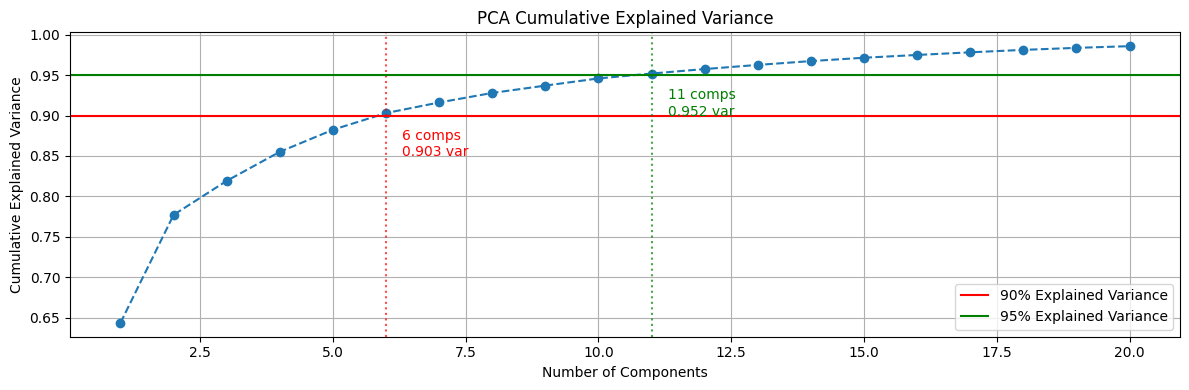

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Get the variance values from PySpark
explained_variance = pca_model.explainedVariance.toArray()
cumulative_variance = np.cumsum(explained_variance)

# Find component index where thresholds are reached
thresholds = [0.90, 0.95]
threshold_indices = [np.argmax(cumulative_variance >= t) for t in thresholds]

# Plot
plt.figure(figsize=(12, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

# Draw horizontal and vertical lines at thresholds
colors = ['r', 'g']
for idx, t in zip(threshold_indices, thresholds):
    comp_number = idx + 1
    cum_var = cumulative_variance[idx]

    # Horizontal line
    plt.axhline(y=t, color=colors[thresholds.index(t)], linestyle='-', label=f'{int(t*100)}% Explained Variance')
    # Vertical line
    plt.axvline(x=comp_number, color=colors[thresholds.index(t)], linestyle=':', alpha=0.7)
    # Annotation
    plt.text(comp_number + 0.3, t - 0.05, f'{comp_number} comps\n{cum_var:.3f} var', color=colors[thresholds.index(t)])

# Labels & Legend
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Doing pyspark ML

In [260]:
from pyspark.ml.feature import PCA

# Try a high number first (e.g., all features)
k_max = len(feature_cols)
pca_model = PCA(k=k_max, inputCol="features", outputCol="pca_features").fit(assembled_df)

# Get explained variance and find smallest k with >= 0.95 cumulative
import numpy as np

vairance_goal = 0.95

explained_variance = np.cumsum(pca_model.explainedVariance.toArray())
k_val = np.argmax(explained_variance >= vairance_goal) + 1  # +1 because index starts at 0
print(f"Using top {k_val} components to explain {vairance_goal}% variance")


Using top 11 components to explain 0.95% variance


In [264]:
assembled_df.head()

Row(SubjectID='sub-058', features=DenseVector([-0.0724, 0.5215, 0.2277, 0.1492, 0.2525, 0.1015, 0.4764, 0.1832, 0.0624, -0.6535, 0.252, -0.0927, -0.609, 0.3205, 1.004, 0.691, 0.034, 0.2799, 0.1959, -0.2542, 0.0, -0.2829, -0.1312, -0.1574, 0.0, 0.252, 0.4113, 0.2905, -0.5083, -0.778, 0.0, 0.2864, 0.0, 0.0, 0.0, -0.4098, 0.0469, -0.1087, 0.0, 0.0, 0.2089, 0.3787, 0.0, 0.053, -0.1114, -0.0483, 0.0, -0.3251, -0.7045, 0.3352, 0.2992, 0.5458, 0.5428, 0.1783, 0.0, -0.1319, 0.0, -0.1517, -0.526, 0.3683, -0.2651, 0.0, -0.7489, 0.0, -0.0452, -0.2115, 0.0, 0.0135, 0.0, -0.1855, 0.2192, 0.3082, 0.009, 0.0842, 0.2583, 0.2347, -0.6746, 0.0026, -0.0278, 0.0, -0.7075, -0.3696, 0.4632, 0.0, -0.4617, -0.7823, 0.0, -0.6571, -0.4038, -0.3923, -0.3143, 0.3745, 0.2688, 0.4742, -0.3334]))

In [261]:
pca = PCA(k=k_val, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_df)
pca_result = pca_model.transform(assembled_df)


In [262]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

# Turn vector into individual PC columns
pca_result = pca_result.withColumn("pca_array", vector_to_array("pca_features"))

# Select label + principal components
for i in range(k_val):
    pca_result = pca_result.withColumn(f"PC{i+1}", col("pca_array")[i])

# Final dataframe with PCs
full_df = pca_result.select("SubjectID", "EpochID", "label", *[f"PC{i+1}" for i in range(k_val)])


AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `EpochID` cannot be resolved. Did you mean one of the following? [`PC1`, `PC10`, `PC11`, `PC2`, `PC3`].;
'Project [SubjectID#41, 'EpochID, 'label, PC1#339889, PC2#339895, PC3#339902, PC4#339910, PC5#339919, PC6#339929, PC7#339940, PC8#339952, PC9#339965, PC10#339979, PC11#339994]
+- Project [SubjectID#41, features#319098, pca_features#339877, pca_array#339884, PC1#339889, PC2#339895, PC3#339902, PC4#339910, PC5#339919, PC6#339929, PC7#339940, PC8#339952, PC9#339965, PC10#339979, pca_array#339884[10] AS PC11#339994]
   +- Project [SubjectID#41, features#319098, pca_features#339877, pca_array#339884, PC1#339889, PC2#339895, PC3#339902, PC4#339910, PC5#339919, PC6#339929, PC7#339940, PC8#339952, PC9#339965, pca_array#339884[9] AS PC10#339979]
      +- Project [SubjectID#41, features#319098, pca_features#339877, pca_array#339884, PC1#339889, PC2#339895, PC3#339902, PC4#339910, PC5#339919, PC6#33

# WHY TF IS IT GETTING DIFFERNET EXPLAINED VARIENCES

# Using the functions created to normalize

In [15]:
from dimensionality_reduction import normalize_power

In [16]:
df_a_norm, df_c_norm = normalize_power(result_group_a, result_group_c)

In [18]:
df_a_norm.show(30)

+---------+--------+---------+-------+--------------------+
|Electrode|WaveBand|SubjectID|EpochID|               Power|
+---------+--------+---------+-------+--------------------+
|      Fp1|   Delta|  sub-020|   ep-0|-0.22287221524788234|
|      Fp1|   Theta|  sub-020|   ep-0| 0.23452256993451262|
|      Fp1|   Alpha|  sub-020|   ep-0|   0.652996502786586|
|      Fp1|    Beta|  sub-020|   ep-0| -0.3898200899055782|
|      Fp1|   Total|  sub-020|   ep-0|                 0.0|
|      Fp2|   Delta|  sub-020|   ep-0|-0.27248447938609727|
|      Fp2|   Theta|  sub-020|   ep-0|  0.3297128332901876|
|      Fp2|   Alpha|  sub-020|   ep-0| 0.45484677266657936|
|      Fp2|    Beta|  sub-020|   ep-0|-0.19059251944965738|
|      Fp2|   Total|  sub-020|   ep-0|                 0.0|
|       F3|   Delta|  sub-020|   ep-0| 0.06729569195896423|
|       F3|   Theta|  sub-020|   ep-0|-0.13344110219088656|
|       F3|   Alpha|  sub-020|   ep-0| 0.14764310589818766|
|       F3|    Beta|  sub-020|   ep-0|-0

In [79]:
import pickle

# Convert to Pandas first
df_a_pd = df_a_norm.toPandas()

df_a_pd.to_pickle("eeg_features_alz_pygrnd6.pkl")
# Save to a pickle file


In [19]:
# put the label for the dataframes
from pyspark.sql.functions import lit
df_a = df_a_norm.withColumn("label", lit(1))
df_c = df_c_norm.withColumn("label", lit(0))
full_df = df_a.union(df_c)

In [20]:
# splitting training and testing


group_a_subjects = (
    full_df.filter(full_df["label"] == 0)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)

group_c_subjects = (
    full_df.filter(full_df["label"] == 1)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)


test_subjects = group_a_subjects[-3:] + group_c_subjects[-3:]

# Filter the full_df to split into train and test based on SubjectID
train_df = full_df.filter(~full_df.SubjectID.isin(test_subjects))
test_df = full_df.filter(full_df.SubjectID.isin(test_subjects))

In [21]:
import dimensionality_reduction

In [22]:
from dimensionality_reduction import prepare_features_for_pca, fit_pca_model, apply_pca_model

In [23]:
#  prepare features for PCA

from dimensionality_reduction import prepare_features_for_pca
train_feat_df, feature_cols = prepare_features_for_pca(train_df)
test_feat_df, _ = prepare_features_for_pca(test_df)

In [26]:
pca_model, k = fit_pca_model(train_feat_df, feature_cols, variance_target=0.95)

# TODO: getting different number of PCA values then playground 4 and 5  so ? Maybe check difference between dataframes if they are different  

In [54]:
k

20

In [55]:
pca_model.explainedVariance.toArray()

array([0.10395404, 0.09881219, 0.09020643, 0.07630289, 0.07345073,
       0.06325665, 0.05846561, 0.05142891, 0.0469734 , 0.0441241 ,
       0.03620411, 0.0345958 , 0.03207046, 0.0291238 , 0.02520649,
       0.02271144, 0.02102785, 0.01968885, 0.01458948, 0.01431236])

In [56]:
sum( pca_model.explainedVariance.toArray())

np.float64(0.9565055762312851)

In [57]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [c for c in train_feat_df.columns if c not in ("SubjectID", "EpochID", "label")]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_train_df = assembler.transform(train_feat_df)

from pyspark.ml.feature import PCA

pca = PCA(k=20, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_train_df)
pca_result = pca_model.transform(assembled_train_df)

In [58]:
# Apply the PCA to both sets
train_pca = apply_pca_model(train_feat_df, feature_cols, pca_model, k)
test_pca = apply_pca_model(test_feat_df, feature_cols, pca_model, k)

In [59]:
train_pca.show(4) # why are there 20 pc's when should be 17 or 18 ? 

[Stage 420:>                                                      (0 + 10) / 11]

+---------+-------+-----+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+------------------+--------------------+--------------------+-------------------+--------------------+
|SubjectID|EpochID|label|                PC1|                 PC2|                 PC3|                 PC4|                 PC5|                 PC6|                 PC7|                 PC8|                 PC9|                PC10|                PC11|                PC12|                PC13|                PC14|                PC15|              PC16|                PC17|                PC18|               PC19|                PC20|
+---------+-------+-----+-------------------+--------------------+--------------------+--------------------+--------

# this is the ML part to test  

In [70]:
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import col

# 1. Automatically get PCA feature columns (PC1, PC2, ..., PCk)
pca_cols = [c for c in train_pca.columns if c.startswith("PC")]

In [71]:
# 2. Assemble vector features
assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
train_df_vec = assembler.transform(train_pca).select("features", "label")
test_df_vec = assembler.transform(test_pca).select("features", "label")

In [72]:
# 3. Define the neural network (MLP)
input_dim = len(pca_cols)  # should match number of PCs used
mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_dim, 100, 2],  # input → hidden (100) → output (2 classes)
    maxIter=1000,
    seed=42
)


In [73]:
# 4. Train and predict
mlp_model = mlp.fit(train_df_vec)
mlp_preds = mlp_model.transform(test_df_vec)

# 5. Evaluate results
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy = evaluator.evaluate(mlp_preds)
print(f"Neural Net Accuracy: {accuracy:.4f}")


Neural Net Accuracy: 0.6196


In [78]:
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Convert Spark predictions to Pandas
preds_pd = mlp_preds.select("prediction", "label").toPandas()

# Accuracy
print("Neural Network Accuracy:", accuracy_score(preds_pd["label"], preds_pd["prediction"]))

# F1 Score (weighted)
print("Weighted F1 Score:", f1_score(preds_pd["label"], preds_pd["prediction"], average="weighted"))

# Full classification report
target_names = ["Control", "Alzheimer's"]
print(classification_report(preds_pd["label"], preds_pd["prediction"], target_names=target_names))


Neural Network Accuracy: 0.6196066921044907
Weighted F1 Score: 0.6176738501867369
              precision    recall  f1-score   support

     Control       0.64      0.55      0.59      1691
 Alzheimer's       0.61      0.69      0.65      1716

    accuracy                           0.62      3407
   macro avg       0.62      0.62      0.62      3407
weighted avg       0.62      0.62      0.62      3407



In [68]:
train_pca.columns

['SubjectID',
 'EpochID',
 'label',
 'PC1',
 'PC2',
 'PC3',
 'PC4',
 'PC5',
 'PC6',
 'PC7',
 'PC8',
 'PC9',
 'PC10',
 'PC11',
 'PC12',
 'PC13',
 'PC14',
 'PC15',
 'PC16',
 'PC17',
 'PC18',
 'PC19',
 'PC20']

In [69]:
from pyspark.ml.feature import VectorAssembler

pca_cols = [c for c in train_pca.columns if c.startswith("PC")]  # e.g., ["PC1", "PC2", ..., "PC11"]

assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
train_df_vec = assembler.transform(train_df)
test_df_vec = assembler.transform(test_df)

IllegalArgumentException: PC1 does not exist. Available: Electrode, WaveBand, SubjectID, EpochID, Power, label

In [66]:
print([c for c in train_df.columns if c.startswith("PC")])


[]


In [64]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import size

# Convert 'features' vector to an array, then compute size
train_df_vec.withColumn("feature_size", size(vector_to_array("features"))).select("feature_size").distinct().show()


[Stage 455:=======================================>            (300 + 10) / 400]

+------------+
|feature_size|
+------------+
|           0|
+------------+



In [61]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Get input size from PCA features
input_dim = len(feature_cols)

mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_dim, 100, 2],  # input → hidden (100 units) → 2 output classes
    maxIter=1000,
    seed=42
)

mlp_model = mlp.fit(train_df_vec)
mlp_preds = mlp_model.transform(test_df_vec)

25/04/05 19:31:57 WARN BlockManager: Putting block rdd_653_12 failed due to exception java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0].
25/04/05 19:31:57 WARN BlockManager: Block rdd_653_12 could not be removed as it was not found on disk or in memory
25/04/05 19:31:57 WARN BlockManager: Putting block rdd_653_23 failed due to exception java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0].
25/04/05 19:31:57 WARN BlockManager: Block rdd_653_23 could not be removed as it was not found on disk or in memory
25/04/05 19:31:57 WARN BlockManager: Putting block rdd_653_22 failed due to exception java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0].
25/04/05 19:31:57 WARN BlockManager: Block rdd_653_22 could not be removed as it was not found on disk or in memory
25/04/05 19:31:57 ERROR Executor: Exception in task 22.0 in stage 444.0 (TID 12607)
j

Py4JJavaError: An error occurred while calling o1429.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 34 in stage 444.0 failed 1 times, most recent failure: Lost task 34.0 in stage 444.0 (TID 12619) (localhost executor driver): java.lang.ArrayIndexOutOfBoundsException: arraycopy: last source index 95 out of bounds for double[0]
	at java.base/java.lang.System.arraycopy(Native Method)
	at org.apache.spark.ml.ann.DataStacker.$anonfun$stack$4(Layer.scala:665)
	at org.apache.spark.ml.ann.DataStacker.$anonfun$stack$4$adapted(Layer.scala:664)
	at scala.collection.immutable.List.foreach(List.scala:431)
	at org.apache.spark.ml.ann.DataStacker.$anonfun$stack$3(Layer.scala:664)
	at scala.collection.Iterator$$anon$10.next(Iterator.scala:461)
	at scala.collection.Iterator$$anon$10.next(Iterator.scala:461)
	at org.apache.spark.storage.memory.MemoryStore.putIterator(MemoryStore.scala:224)
	at org.apache.spark.storage.memory.MemoryStore.putIteratorAsValues(MemoryStore.sca